# Frequencies

Using polars_corpus to do basic corpus searching

In [1]:
import sys
if '..' not in sys.path:
    sys.path.append('..')

import polars as pl
import polars.selectors as cs
import polars_corpus as plc
import seaborn as sns
#import matplotlib.pyplot as plt

In [2]:
bnc = pl.read_parquet("bnc.parquet")

In [3]:
bnc.head(10)

token,lemma,pos,c5,sent_tag,mode,text_type,file_id,speaker_id
str,str,str,str,str,cat,cat,cat,str
"""FACTSHEET""","""factsheet""","""SUBST""","""NN1""","""B""","""written""","""NONAC""","""A00""",null
"""WHAT""","""what""","""PRON""","""DTQ""","""I""","""written""","""NONAC""","""A00""",null
"""IS""","""be""","""VERB""","""VBZ""","""I""","""written""","""NONAC""","""A00""",null
"""AIDS""","""aids""","""SUBST""","""NN1""","""I""","""written""","""NONAC""","""A00""",null
"""?""",null,"""STOP""","""PUN""","""I""","""written""","""NONAC""","""A00""",null
"""AIDS""","""aids""","""SUBST""","""NN1""","""B""","""written""","""NONAC""","""A00""",null
"""(""",null,"""STOP""","""PUL""","""I""","""written""","""NONAC""","""A00""",null
"""Acquired""","""acquire""","""VERB""","""VVN-AJ0""","""I""","""written""","""NONAC""","""A00""",null
"""Immune""","""immune""","""ADJ""","""AJ0""","""I""","""written""","""NONAC""","""A00""",null


Brezina pg. 26

In [4]:
the = (
    bnc.filter(mode="spoken")
    .group_by("file_id")
    .agg(
        (
            pl.col("lemma").len().alias("n"),
            (pl.col("lemma") == "the").sum().alias("the"),
            (pl.col("lemma") == "i").sum().alias("i"),
            (pl.col("lemma") == "you").sum().alias("you"),
        )
    )
    .select("file_id", (cs.numeric().exclude("n") / pl.col("n") * 10000))
    .sort(by="file_id")
)

the.head(10)

file_id,the,i,you
cat,f64,f64,f64
"""D8Y""",351.247854,150.534795,143.932391
"""D90""",418.747599,257.395313,142.14368
"""D91""",466.304523,371.645243,173.721293
"""D92""",551.431601,466.59597,254.506893
"""D94""",91.743119,581.039755,183.486239
"""D95""",404.672276,248.007086,177.701506
"""D96""",509.304603,254.652302,264.446621
"""D97""",283.304076,394.480203,184.318315
"""DCH""",277.288276,273.660205,137.866694


<Axes: xlabel='Count', ylabel='the'>

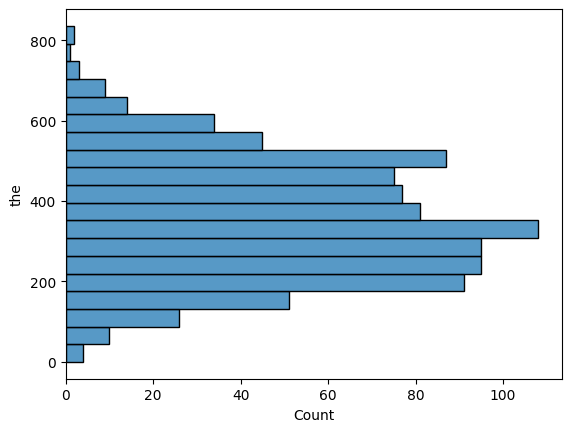

In [5]:
sns.histplot(the.to_pandas(), y="the")

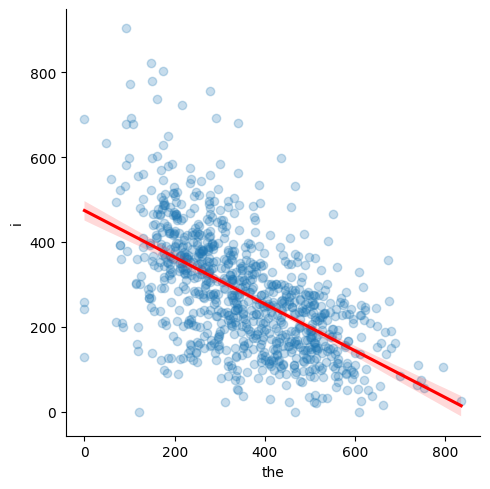

In [6]:
sns.lmplot(
    the.to_pandas(),
    x="the",
    y="i",
    scatter_kws={"alpha": 0.25},
    line_kws={"color": "red"},
)

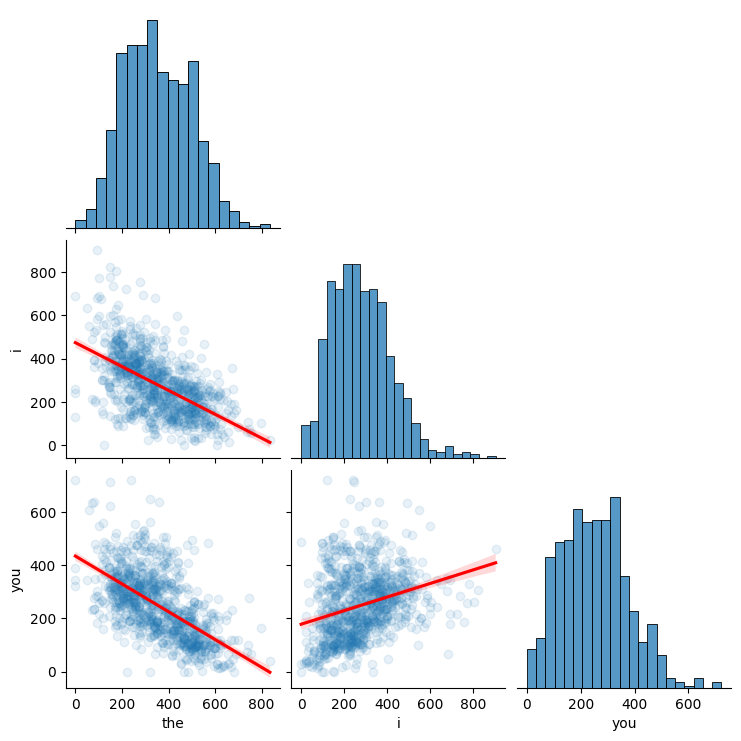

In [7]:
sns.pairplot(
    the.to_pandas(),
    vars=["the", "i", "you"],
    kind="reg",
    corner=True,
    plot_kws={"scatter_kws": {"alpha": 0.1}, "line_kws": {"color": "red"}},
)

In [ ]:
hits = bnc.filter(
    pl.col("lemma").is_in(["very", "really", "rather", "quite"]), pl.col("c5") == "AV0"
)
counts = (
    hits.group_by("lemma", "text_type")
    .agg(pl.len().alias("count"))
    .with_columns(
        (pl.col("count") / pl.col("count").sum().over("text_type") * 100).alias("pct")
    )
)
counts

In [9]:
chart = counts.plot.bar(x="pct", y="text_type", color="hw").properties(
    height=500, width=800
)
chart.encoding.y.title = "Text type"
chart

ModuleUpgradeRequiredError: altair>=5.4.0 is required for `.plot`

In [10]:
bnc.filter(pl.col("token") == "really").group_by("c5").len()

c5,len
str,u32
"""UNC""",1
"""AV0""",44325


In [6]:
# r = plc.Concordance(bnc, '[tok="very|really"]')

In [7]:
# hits = plc.with_spans(bnc, r.spans)  # .filter(pl.col('spans')!='O')

In [8]:
# hits.filter(pl.col("spans") != "O")

tok,c5,pos,mode,text_type,fileid,sentid,hw,spans
str,str,str,str,str,str,str,str,str
"""very""","""AV0""","""ADV""","""written""","""NONAC""","""A00""","""A00:25""","""very""","""B"""
"""very""","""AV0""","""ADV""","""written""","""NONAC""","""A00""","""A00:41""","""very""","""B"""
"""very""","""AV0""","""ADV""","""written""","""NONAC""","""A00""","""A00:60""","""very""","""B"""
"""very""","""AV0""","""ADV""","""written""","""NONAC""","""A00""","""A00:90""","""very""","""B"""
"""very""","""AV0""","""ADV""","""written""","""NONAC""","""A00""","""A00:182""","""very""","""B"""
…,…,…,…,…,…,…,…,…
"""very""","""AV0""","""ADV""","""spoken""","""CONVRSN""","""KSV""","""KSV:5759""","""very""","""B"""
"""very""","""AV0""","""ADV""","""spoken""","""CONVRSN""","""KSV""","""KSV:5771""","""very""","""B"""
"""really""","""AV0""","""ADV""","""spoken""","""CONVRSN""","""KSV""","""KSV:5783""","""really""","""B"""


In [11]:
ratio = (
    hits.group_by("text_type")
    .agg(
        ((pl.col("tok") == "very").sum() / (pl.col("tok") == "really").sum()).alias(
            "ratio"
        )
    )
    .sort(by="ratio")
)
ratio

text_type,ratio
str,f64
"""CONVRSN""",0.71413
"""FICTION""",2.062849
"""OTHERSP""",2.117939
"""NEWS""",3.091058
"""OTHERPUB""",3.228697
"""UNPUB""",4.162037
"""NONAC""",4.347436
"""ACPROSE""",6.33641
